# Starter notebook: loading + visualizing CI vs hearing EEG

Goal of this notebook: get you comfortable loading the EEG dataset, looking around the file structure, and producing the four plots you'll keep coming back to during analysis:

1. **Raw waveform** -- a few seconds of voltage at one electrode. CI and hearing recordings look very different here.
2. **Power spectrum (PSD)** -- how much energy is at each frequency. CI artifact is a comb of harmonics; clean brain signal is a smooth 1/f curve.
3. **Spectrogram** -- power vs frequency vs time on a 7x3 grid (one panel per channel). The same view as the PSD but resolved in time, so you can see the artifact switch on and off with the stimulus.
4. **ERP (event-related potential)** -- average response time-locked to a stimulus, plotted as an MNE butterfly (all 21 channels overlaid, colored by scalp position). One of the goals of denoising is to make these readable.

To keep things simple and consistent across plots, we **focus on the first stimulus block** of each recording (a ~60-second window bracketed by event codes `'10'` and `'11'`). Every plot below uses that same window.

### Setup
- This zarr was produced from the original `.set/.fdt` files on the lab server. Only step applied: a 2 Hz high-pass to remove slow DC drift.
- 113 recordings total: 68 CI (cochlear-implant users) + 45 hearing (controls).
- 21 channels, 16,384 Hz, ~12 minutes each.

In [1]:
import json

import matplotlib.pyplot as plt
import mne
import numpy as np
import zarr

mne.set_log_level('WARNING')

ZARR_PATH = 'eeg_raw.zarr'

## 1. What's inside the zarr?

Zarr is a folder-based hierarchical array format. Think of it like an HDF5 file but stored as a directory tree you can browse. You open it like a Python dict.

Top level has two groups: `ci/` and `hearing/`. Inside each is one sub-group per recording, named like `noise0_perm1` (CI) or `hearing3_perm2` (hearing).

- The number (e.g. `0`, `3`) is an internal recording index.
- `perm{1,2,3}` is the stimulus permutation. There are 3 different stimulus orderings; each subject was assigned one. Stimuli only line up across recordings with the same `perm`.

In [2]:
store = zarr.open(ZARR_PATH, mode='r')

print('Top-level groups:', list(store))
print(f'  ci      : {len(list(store["ci"]))} recordings')
print(f'  hearing : {len(list(store["hearing"]))} recordings')

print('\nFirst 5 CI recordings :', sorted(store['ci'])[:5])
print('First 5 hearing recs  :', sorted(store['hearing'])[:5])

Top-level groups: ['ci', 'hearing']
  ci      : 68 recordings
  hearing : 45 recordings

First 5 CI recordings : ['noise0_perm1', 'noise0_perm2', 'noise0_perm3', 'noise10_perm1', 'noise10_perm2']
First 5 hearing recs  : ['hearing10_perm1', 'hearing10_perm2', 'hearing10_perm3', 'hearing11_perm1', 'hearing11_perm3']


## 2. What's inside one recording?

Each recording group has a handful of arrays and a metadata dict (`attrs`).

- **`data`** - the actual EEG: shape `(n_channels, n_samples)`, float64, in volts (SI units - same as MNE).
- **`annotations_onset` / `annotations_duration`** - event times in seconds, paired with descriptions stored in `attrs['annotations_description']` (a JSON-encoded list of strings).
- **`norm_mean` / `norm_std`** - per-channel z-score stats, for downstream pipelines that train ML models.
- **`attrs`** - channel names, sample rate, filter settings, participant ID, etc.

Note: Durations are all 0. These are point events, not intervals - the duration field is just there because MNE's Annotations always carries one. The actual "event" is instantaneous.

In [3]:
g = store['ci']['noise0_perm1']

print('Arrays in this recording:')
for name in g.array_keys():
    a = g[name]
    print(f'  {name:25s}  shape={a.shape}  dtype={a.dtype}')

print('\nMetadata (attrs):')
for k, v in g.attrs.items():
    s = str(v)
    if len(s) > 90:
        s = s[:90] + '...'
    print(f'  {k:30s} = {s}')

Arrays in this recording:
  annotations_duration       shape=(8960,)  dtype=float64
  annotations_onset          shape=(8960,)  dtype=float64
  norm_mean                  shape=(21, 1)  dtype=float64
  data                       shape=(21, 12484608)  dtype=float64
  norm_std                   shape=(21, 1)  dtype=float64

Metadata (attrs):
  sfreq                          = 16384.0
  ch_names                       = ['Fp1', 'Fz', 'F3', 'F7', 'T7', 'C3', 'Cz', 'Pz', 'P3', 'P7', 'O1', 'Fp2', 'F8', 'F4', 'C4...
  ch_types                       = ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg'...
  participant_id                 = 0
  perm                           = 1
  source_file                    = /quobyte/millerlmgrp//CMPy2/MarkerFixed/0901y2.set
  annotations_description        = ["10", "25", "100", "104", "106", "108", "110", "112", "114", "116", "118", "120", "98", "...
  interpolated_channels          = []
  filter_lfreq                

## 3. Helper: load a zarr recording as an MNE `Raw` object, then crop to the first stimulus block

MNE is the standard Python toolkit for EEG analysis. Almost every plot or operation you'll want to do takes an `mne.io.Raw` as input. So we write one small helper to lift a zarr group into a `Raw`.

Notes for beginners:
- `mne.create_info` builds the metadata struct (channel names, types, sample rate).
- `mne.io.RawArray` wraps a numpy array `(n_channels, n_samples)` of voltages into a `Raw`.
- We attach the event annotations and set the standard 10-20 electrode montage so MNE can compute topomaps if needed.

Right after loading, we **crop to the first stimulus block** - the window from the first `'10'` annotation to the first following `'11'`. After this step, `raw_ci.times[0]` is 0 again (MNE re-zeros the time axis on `crop()`), and every plot below operates on this single ~60 s window.

In [ ]:
def zarr_to_raw(group):
    """Load a zarr recording group into an mne.io.RawArray with annotations + montage."""
    data = np.array(group['data'])                       # (n_ch, n_samples), volts
    sfreq = float(group.attrs['sfreq'])
    ch_names = list(group.attrs['ch_names'])

    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    raw = mne.io.RawArray(data, info, verbose=False)

    # Attach event annotations (onsets + descriptions like '100', '104', ...)
    onsets    = np.array(group['annotations_onset'])
    durations = np.array(group['annotations_duration'])
    descs     = json.loads(group.attrs['annotations_description'])
    n = min(len(onsets), len(descs))                     # safety crop
    raw.set_annotations(mne.Annotations(
        onset=onsets[:n], duration=durations[:n], description=descs[:n],
    ))

    # Standard 10-20 positions for topomap plots; M1/M2 mastoids aren't in 10-20
    # so on_missing='ignore' silently leaves them positionless (fine for everything
    # except topomaps).
    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage, on_missing='ignore', match_case=False, verbose=False)
    return raw


def first_block_window(raw, on_code='10', off_code='11'):
    """(start_s, end_s) of the first '10' -> '11' window in this recording, or None."""
    onsets = raw.annotations.onset
    descs = list(map(str, raw.annotations.description))
    t10 = next((onsets[i] for i in range(len(descs)) if descs[i] == on_code), None)
    t11 = next((onsets[i] for i in range(len(descs))
                if descs[i] == off_code and onsets[i] > (t10 if t10 is not None else -1)), None)
    if t10 is None or t11 is None:
        return None
    return float(t10), float(t11)


def crop_to_first_block(raw):
    """Return a copy of `raw` cropped to its first stimulus block."""
    w = first_block_window(raw)
    if w is None:
        print(f'  WARNING: no 10/11 block found, returning raw unchanged')
        return raw
    t0, t1 = w
    return raw.copy().crop(tmin=t0, tmax=t1, verbose=False)


# Pick one CI + one hearing recording. Any name from store['ci'] / store['hearing']
CI_NAME = 'noise0_perm1'
HR_NAME = 'hearing10_perm1'

raw_ci_full = zarr_to_raw(store['ci'][CI_NAME])
raw_hr_full = zarr_to_raw(store['hearing'][HR_NAME])

raw_ci = crop_to_first_block(raw_ci_full)
raw_hr = crop_to_first_block(raw_hr_full)

for label, full, cropped in [('CI', raw_ci_full, raw_ci), ('Hearing', raw_hr_full, raw_hr)]:
    sf = full.info['sfreq']
    print(f'{label:8s} -- full: {full.n_times/sf:6.1f} s, {len(full.annotations)} annot  ->  '
          f'first block: {cropped.n_times/sf:5.1f} s, {len(cropped.annotations)} annot')


CI       -- full:  762.0 s, 8960 annot  ->  first block:  65.0 s, 716 annot
Hearing  -- full:  772.0 s, 8960 annot  ->  first block:  65.0 s, 716 annot


## 4. What event codes are in the first block?

Each annotation has a string description. The lab paradigm uses numeric codes like `'100'`, `'101'`, `'104'`, etc. Quick look at the distribution inside our cropped first block.

In [5]:
from collections import Counter

for label, raw in [('CI ' + CI_NAME, raw_ci), ('HR ' + HR_NAME, raw_hr)]:
    descs = list(map(str, raw.annotations.description))
    counts = Counter(descs)
    top = counts.most_common(8)
    print(f'{label}: {len(descs)} total annotations, top 8 codes:')
    for code, n in top:
        print(f'    {code!r:>6}: {n}')
    print()

CI noise0_perm1: 716 total annotations, top 8 codes:
     '100': 80
     '104': 80
     '106': 80
      '98': 80
     '108': 67
     '110': 58
     '112': 49
     '114': 43

HR hearing10_perm1: 716 total annotations, top 8 codes:
     '100': 80
     '104': 80
     '106': 80
      '98': 80
     '108': 67
     '110': 58
     '112': 49
     '114': 43



## 5. Look at the raw time-domain data

This is the most direct way to see what makes CI EEG hard. We'll plot 2 seconds at electrode `Cz` (top of the head, closest to where the CI artifact dominates) taken from the middle of the cropped block.

What to expect:
- **Hearing** recording: a wiggle in the tens of uV range -- normal EEG.
- **CI** recording: a much larger, much faster signal. Often hundreds or thousands of uV peak-to-peak. That extra fast activity *is* the CI artifact -- electrical pulses from the implant leaking into the EEG.

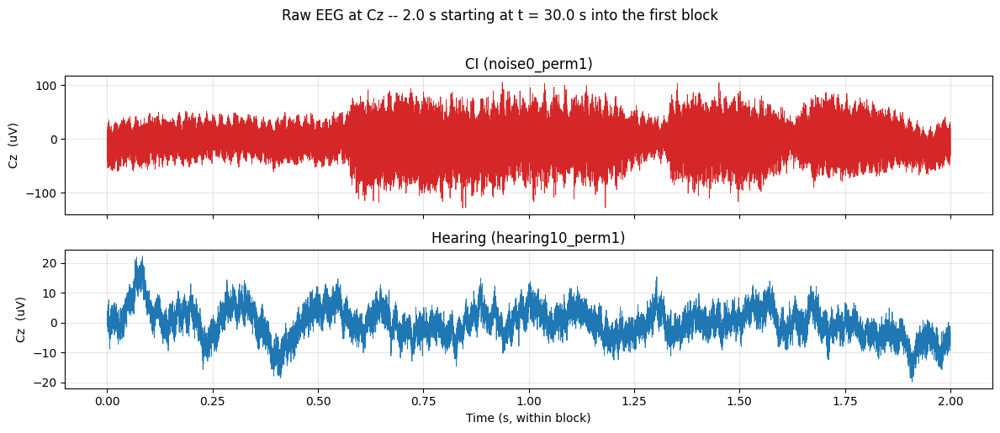

In [6]:
CH = 'Cz'
T_START_S = 30.0    # 30 s into the cropped block = ~midway
WINDOW_S = 2.0      # show 2 seconds

sf = raw_ci.info['sfreq']
s0 = int(T_START_S * sf)
n  = int(WINDOW_S * sf)
t  = np.arange(n) / sf

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, raw, label, color in [(axes[0], raw_ci, f'CI ({CI_NAME})', 'C3'),
                              (axes[1], raw_hr, f'Hearing ({HR_NAME})', 'C0')]:
    d = raw.get_data(picks=CH, start=s0, stop=s0 + n)[0] * 1e6   # V -> uV
    ax.plot(t, d, color=color, linewidth=0.6)
    ax.set_ylabel(f'{CH}  (uV)')
    ax.set_title(label)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Time (s, within block)')
fig.suptitle(f'Raw EEG at {CH} -- {WINDOW_S} s starting at t = {T_START_S} s into the first block', y=1.02)
plt.tight_layout()
plt.show()


## 6. Power spectrum (PSD)

The PSD shows how much energy is at each frequency. It's the easiest way to spot CI artifact and line noise. Computed over the entire cropped block (~60 s).

What to expect:
- **Hearing**: a fairly smooth 1/f-shaped curve (more power at low frequencies, less at high). Plus a small bump at 60 Hz (US line noise) and its harmonics.
- **CI**: same general shape *plus* a series of sharp spikes -- a comb at the CI's pulse rate (~1237 Hz here) and its harmonics. Those spikes are why the time-domain plot looked so different.

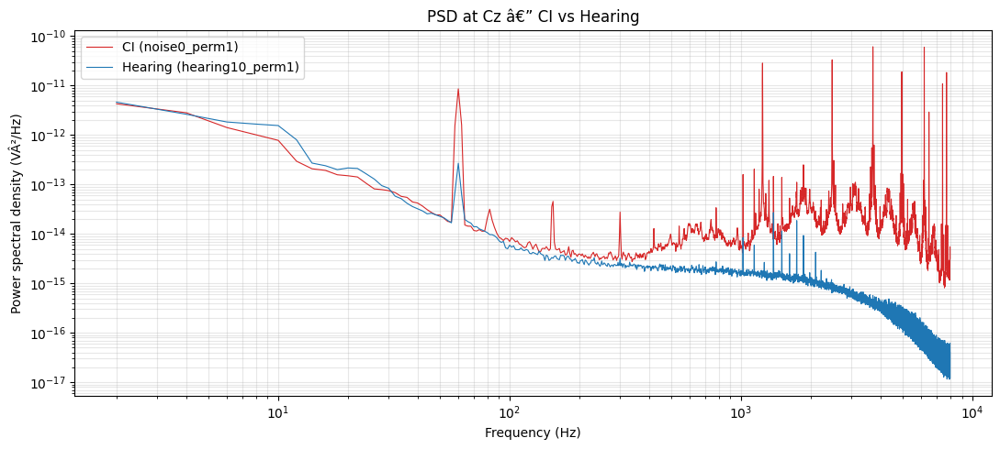

In [7]:
FMIN, FMAX = 1.0, 8000.0

psd_ci = raw_ci.compute_psd(fmin=FMIN, fmax=FMAX, n_fft=8192, picks=CH, verbose=False)
psd_hr = raw_hr.compute_psd(fmin=FMIN, fmax=FMAX, n_fft=8192, picks=CH, verbose=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.semilogy(psd_ci.freqs, psd_ci.get_data().mean(0), label=f'CI ({CI_NAME})', color='C3', linewidth=0.8)
ax.semilogy(psd_hr.freqs, psd_hr.get_data().mean(0), label=f'Hearing ({HR_NAME})', color='C0', linewidth=0.8)
ax.set_xscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power spectral density (VÂ²/Hz)')
ax.set_title(f'PSD at {CH} â€” CI vs Hearing')
ax.legend()
ax.grid(which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Spectrogram -- power vs frequency vs time

The PSD above collapses the cropped block into one curve. A spectrogram keeps the time axis: how does the spectral content change *within* the block?

We compute the short-time Fourier transform (STFT) of the whole cropped block:
- `n_fft = 4096`, `hop = 2048` (50 % overlap) -- ~4 Hz frequency resolution, 0.125 s time resolution at 16,384 Hz.
- frequency axis clipped to **0-2000 Hz** so we can see the fundamental CI artifact line at ~1237 Hz and a harmonic, plus all of the brain band.
- color = power in dB, percentile-clipped per panel so internal structure isn't washed out by the brightest bin.
- white dashed reference lines at **100 Hz** (top of the cortical band) and **250 Hz** (no-man's-land between brain rhythms and the CI fundamental).

What to expect on the 7x3 grid (one panel per channel):
- **Hearing**: dark canvas with faint 1/f shading and small bumps at line-noise harmonics (60/120/180 Hz). The 100 Hz reference line sits near the top of the bright region.
- **CI**: a bright horizontal stripe at ~1237 Hz (the implant's pulse rate) plus harmonics that fade upward. Stripe stays roughly constant across the block while stimuli are present.

CI (noise0_perm1): cropped block = 65.0 s, 522 STFT frames
         color range: [-25.9, 17.0] dB


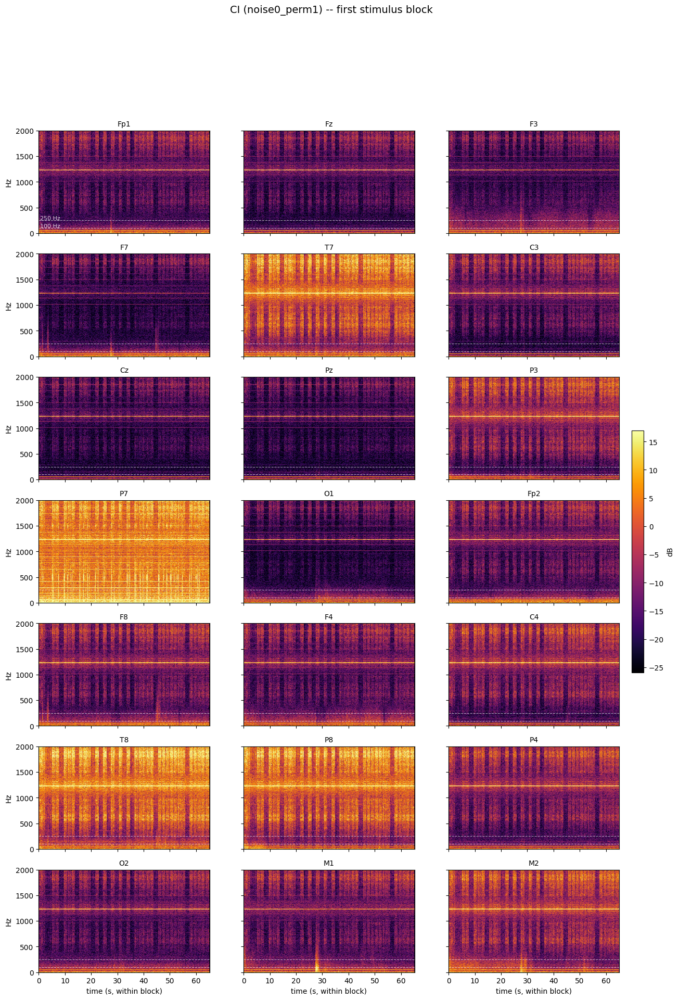

Hearing (hearing10_perm1): cropped block = 65.0 s, 522 STFT frames
         color range: [-34.8, 7.3] dB


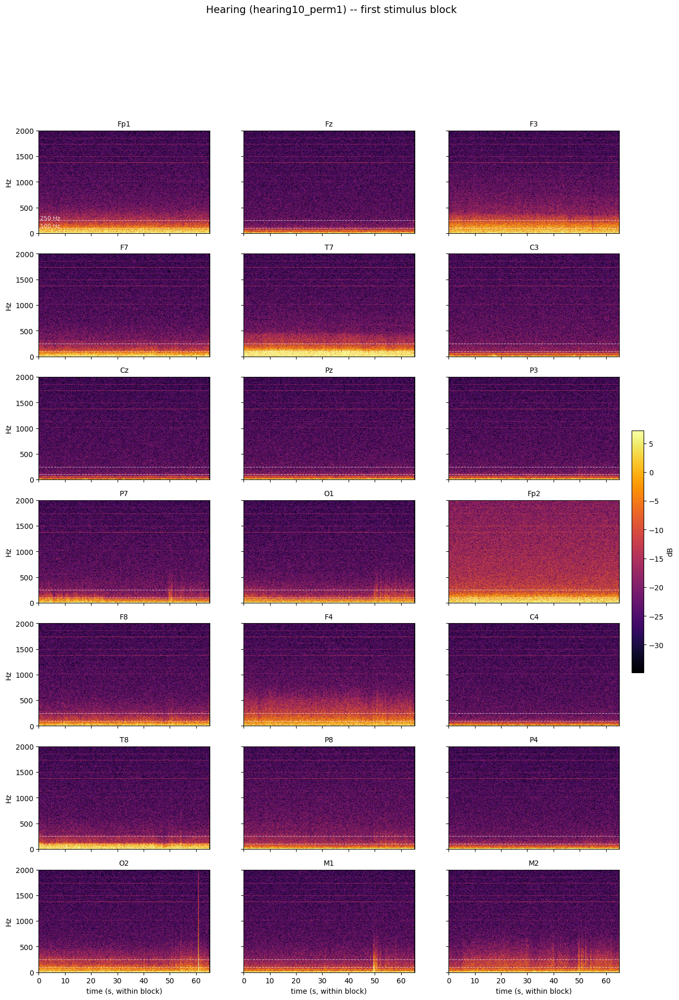

In [8]:
from scipy.signal import stft as scipy_stft

SPEC_NFFT = 4096
SPEC_HOP  = 2048
SPEC_FMAX = 2000.0       # Hz, upper edge of the y-axis
SPEC_CMAP = 'inferno'


def compute_spectrogram(raw):
    """STFT of the entire (cropped) Raw, returns ch_names, f, t, power_db."""
    # V -> uV. Without this, dB values land below the epsilon floor (1e-12) and
    # most of the plot clips to black.
    data_uV = raw.get_data() * 1e6
    f, t, Z = scipy_stft(data_uV, fs=raw.info['sfreq'], nperseg=SPEC_NFFT,
                         noverlap=SPEC_NFFT - SPEC_HOP, axis=-1)
    power_db = 10 * np.log10(np.abs(Z) ** 2 + 1e-12)
    return raw.ch_names, f, t, power_db


def plot_spec_panel(ch_names, f_stft, t_stft, power_db, title,
                    vmin, vmax, fmax=SPEC_FMAX):
    fig, axes = plt.subplots(7, 3, figsize=(15, 21), sharex=True, sharey=True)
    f_mask = f_stft <= fmax
    for ch_i in range(len(ch_names)):
        ax = axes.flat[ch_i]
        im = ax.pcolormesh(t_stft, f_stft[f_mask], power_db[ch_i, f_mask],
                           shading='gouraud', cmap=SPEC_CMAP, vmin=vmin, vmax=vmax)
        ax.set_title(ch_names[ch_i], fontsize=10)
        ax.set_ylim(0, fmax)
        ax.axhline(100, color='white', ls='--', lw=0.8, alpha=0.6)
        ax.axhline(250, color='white', ls='--', lw=0.8, alpha=0.6)
    for ax in axes[-1, :]:
        ax.set_xlabel('time (s, within block)')
    for ax in axes[:, 0]:
        ax.set_ylabel('Hz')
    axes[0, 0].text(0.5, 108, '100 Hz', color='white', fontsize=8, alpha=0.8)
    axes[0, 0].text(0.5, 258, '250 Hz', color='white', fontsize=8, alpha=0.8)
    fig.suptitle(title, fontsize=14, y=0.995)
    fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label='dB')
    plt.show()


def show_spec(raw, label):
    """Compute the spectrogram of the (cropped) Raw and plot it as a 7x3 grid."""
    ch_names, f, t, power_db = compute_spectrogram(raw)
    print(f'{label}: cropped block = {raw.n_times / raw.info["sfreq"]:.1f} s, '
          f'{power_db.shape[2]} STFT frames')
    # per-panel color scale: 5th .. 99th percentile of in-band power
    f_mask = f <= SPEC_FMAX
    v = power_db[:, f_mask]
    vmin, vmax = float(np.percentile(v, 5)), float(np.percentile(v, 99))
    print(f'         color range: [{vmin:.1f}, {vmax:.1f}] dB')
    plot_spec_panel(ch_names, f, t, power_db,
                    f'{label} -- first stimulus block', vmin, vmax)


show_spec(raw_ci, f'CI ({CI_NAME})')
show_spec(raw_hr, f'Hearing ({HR_NAME})')


## 8. ERP -- average response time-locked to a stimulus

An *ERP* (event-related potential) is the average of many short EEG snippets cut around the same stimulus. A single click's brain response is tiny (microvolts), buried in much larger ongoing activity. Averaging dozens of trials cancels random noise and surfaces the consistent stimulus-locked response.

- Window: **-200 ms to +800 ms** around code `'100'` (the click marker at the start of each voicing period).
- Plot style: MNE butterfly with `spatial_colors=True` (channel color = electrode position on the scalp; nearby electrodes get similar colors).

Because we cropped to the first block, the ERP is averaged over just the trials inside that ~60 s window (~80 trials per recording instead of ~500 across the whole recording). The waveform shape is the same, the noise floor is a bit higher.

What to expect:
- **Hearing**: a small biphasic deflection -- N1 negative peak at ~80-120 ms, P2 positive peak at ~150-200 ms, peaks in the tens of microvolts.
- **CI raw**: a much larger waveform that mostly reflects CI artifact riding on top of the brain response. Y-axis values will be one or two orders of magnitude bigger than hearing. 

Note: The CI and hearing ERPs have different scales. You can see that the magnitude of the CI ERPs are much higher.

CI      (noise0_perm1): 79 epochs averaged into ERP
Hearing (hearing10_perm1): 79 epochs averaged into ERP


C:\Users\shyam\AppData\Local\Temp\ipykernel_24816\396520693.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


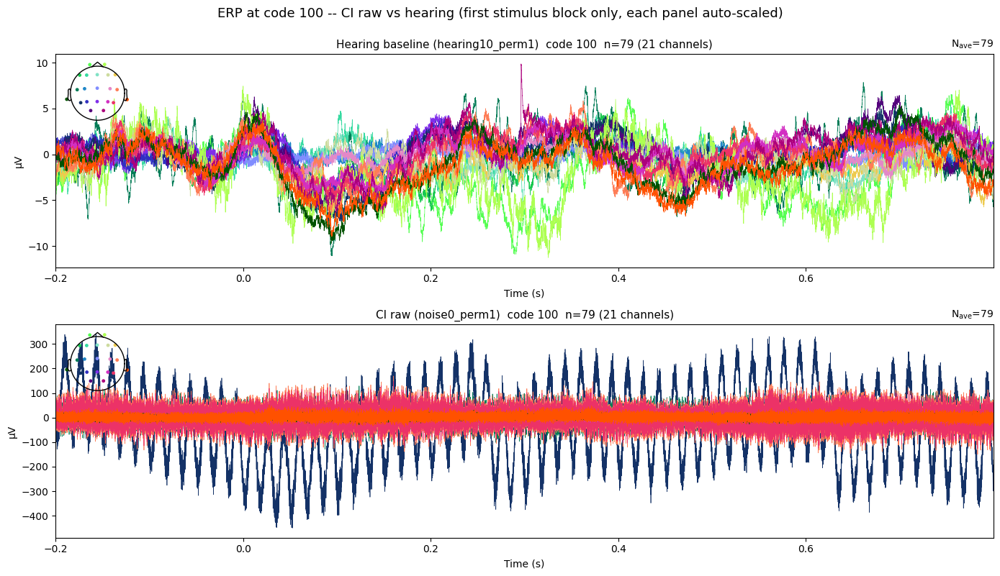

In [9]:
ERP_TMIN = -0.2
ERP_TMAX =  0.8
ERP_BL   = (-0.2, 0.0)
STIM_CODE = '100'


def make_evoked(raw, code, tmin=ERP_TMIN, tmax=ERP_TMAX, baseline=ERP_BL):
    """mne.Epochs(...).average() with a single stimulus code."""
    events, event_id = mne.events_from_annotations(
        raw, event_id={code: int(code)}, verbose=False,
    )
    epochs = mne.Epochs(
        raw, events, event_id=event_id,
        tmin=tmin, tmax=tmax, baseline=baseline,
        preload=True, verbose=False,
    )
    return epochs.average(), len(epochs)


evk_ci, n_ci = make_evoked(raw_ci, STIM_CODE)
evk_hr, n_hr = make_evoked(raw_hr, STIM_CODE)
print(f'CI      ({CI_NAME}): {n_ci} epochs averaged into ERP')
print(f'Hearing ({HR_NAME}): {n_hr} epochs averaged into ERP')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
evk_hr.plot(axes=axes[0], show=False, spatial_colors=True, time_unit='s')
axes[0].set_title(f'Hearing baseline ({HR_NAME})  code {STIM_CODE}  '
                  f'n={n_hr} (21 channels)', fontsize=11)

evk_ci.plot(axes=axes[1], show=False, spatial_colors=True, time_unit='s')
axes[1].set_title(f'CI raw ({CI_NAME})  code {STIM_CODE}  '
                  f'n={n_ci} (21 channels)', fontsize=11)

for ax in axes:
    ax.set_xlabel('Time (s)')

fig.suptitle(f'ERP at code {STIM_CODE} -- CI raw vs hearing (first stimulus block only, '
             f'each panel auto-scaled)', fontsize=13, y=0.995)
plt.tight_layout()
plt.show()
